In [1]:
from modules.data_services.data_utils import load_btc_benchmark
from modules.visualization.plots import plot_positions, plot_pnl, plot_zscore
from modules.performance.strategy import Strategy

In [2]:
interval = "1h"
fee_rate = 0.0005
initial_cash = 100000
risk_free_rate = 0

ticker_x = "BNBUSDT"
ticker_y = "UNIUSDT"

test_beta_calculation_start = "2024-01-01"
test_start = "2024-03-01"
test_end = "2024-04-01"

entry_threshold = 2.5
exit_threshold = 0.8
stop_loss = 1.2
rolling_window = 50

In [3]:
bt_1 = Strategy(
    ticker_x=ticker_x,
    ticker_y=ticker_y,
    start=test_beta_calculation_start,
    end=test_end,
    interval=interval,
    fee_rate=fee_rate,
    initial_cash=initial_cash,
    risk_free_rate_annual=risk_free_rate,
    source="log",
    beta_hedge="dynamic_hedge",
)

result_1 = bt_1.run_strategy(
    rolling_window=rolling_window,
    entry_threshold=entry_threshold,
    exit_threshold=exit_threshold,
    stop_loss=stop_loss,
    test_start=test_start,
    test_end=test_end,
    beta_calculation_start=test_beta_calculation_start,
)

In [4]:
result_1.data

,BNBUSDT,UNIUSDT,z_score,beta,entry_thr,exit_thr,sl_thr,q_x,q_y,w_x,w_y,signal,position,total_return,total_fees,net_return,total_return_pct,net_return_pct
open_time,,,,,,,,,,,,,,,,,,
2024-03-01 00:00:00,404.3,11.212,-1.212339,0.452527,2.5,0.8,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 01:00:00,405.3,11.221,-0.819265,0.452611,2.5,0.8,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 02:00:00,405.4,11.060,-0.739732,0.452722,2.5,0.8,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 03:00:00,405.6,11.051,-0.456797,0.452905,2.5,0.8,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-03-01 04:00:00,406.9,11.015,-0.458246,0.453075,2.5,0.8,None,0.000000,0.000000,None,None,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-31 20:00:00,606.9,13.022,-0.894703,0.665360,2.5,0.8,3.65614,65.611796,-4528.913397,0.398198,0.601802,0.0,1.0,372.173292,1755.058794,-1382.885502,0.003722,-0.013829
2024-03-31 21:00:00,606.1,12.945,-0.791104,0.665635,2.5,0.8,None,0.000000,0.000000,None,None,0.0,0.0,75.936397,1804.255840,-1728.319444,0.000759,-0.017283
2024-03-31 22:00:00,605.8,12.906,-0.551660,0.665915,2.5,0.8,None,0.000000,0.000000,None,None,0.0,0.0,75.936397,1804.255840,-1728.319444,0.000759,-0.017283


In [5]:
result_1.stats

,gross,net
metric,,
total_return,0.0008,-0.0173
cagr,0.0090,-0.1854
volatility,0.0045,0.0046
volatility_annual,0.4256,0.4277
max_drawdown,-0.1508,-0.1608
win_count,7.0000,7.0000
lose_count,11.0000,11.0000
win_rate,0.3889,0.3889
max_win,0.0970,0.0964


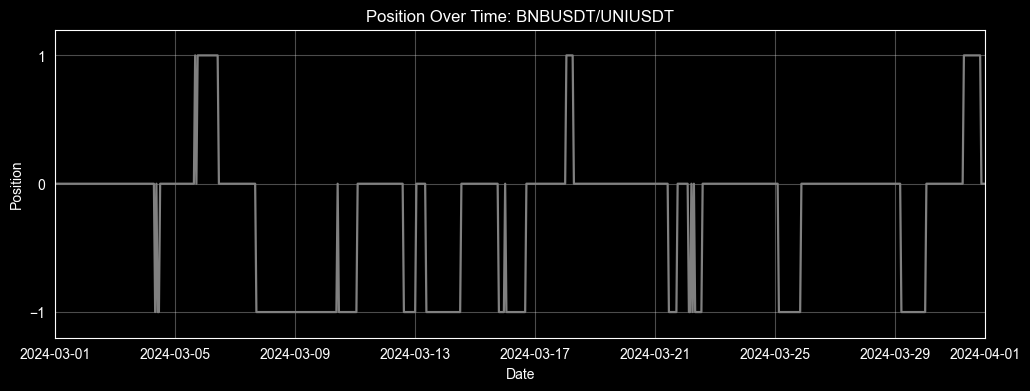

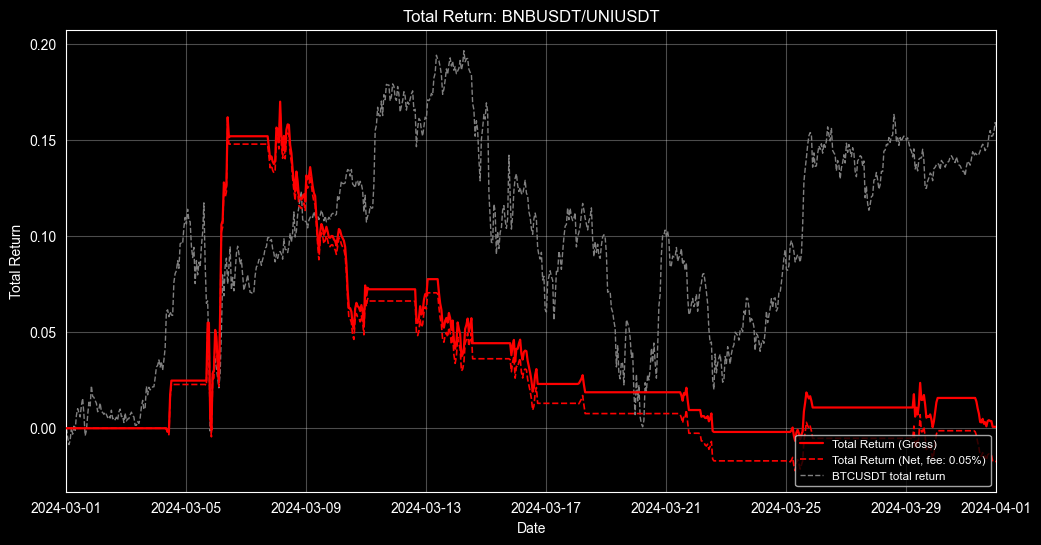

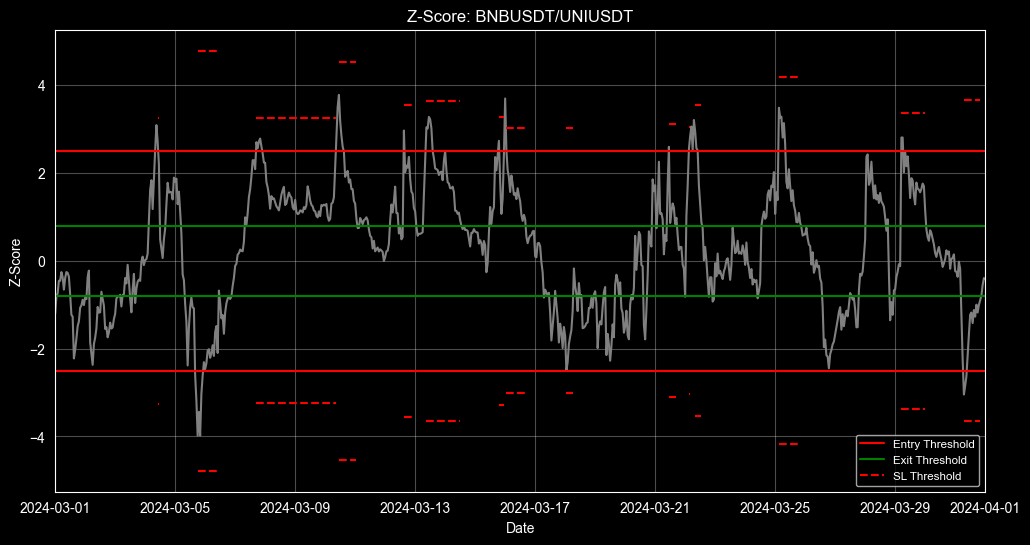

In [6]:
plot_positions(result_1, show=True)
btc_data = load_btc_benchmark(
    test_start=test_start,
    test_end=test_end,
    interval=interval,
)
plot_pnl(result_1, btc_data, show=True)
plot_zscore(result_1, show=True)